<a href="https://colab.research.google.com/github/GustavoHDLC1/Colab_Files_PADP/blob/main/Representacion_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.9 MB/s eta 0:00:00


In [2]:
from gensim.models import KeyedVectors
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords

In [3]:
import nltk
nltk.download('stopwords', quiet=True)
stopwords_es = stopwords.words('spanish')

In [4]:
model = api.load('fasttext-wiki-news-subwords-300')

[==================================================] 100.0% 958.5/958.4MB downloaded


In [6]:
df = pd.read_csv('Ejercicios de Representación de textos - Embeddings.csv')
df

,frase
0,La ciberseguridad protege la información digit...
1,La inteligencia artificial transforma múltiple...
2,"El baloncesto combina velocidad, técnica y tra..."
3,El hardware y el software son complementarios ...
4,La democracia permite la participación ciudada...
...,...
143,La natación es una disciplina que fortalece to...
144,Los atletas requieren entrenamiento constante ...
145,Las políticas públicas buscan atender necesida...
146,Los partidos políticos representan diferentes ...


In [7]:
palabras = list(set(
    re.findall(r'\b\w+\b', " ".join(df["frase"].str.lower()))
))

palabras = list(palabras)
len(palabras)

92

In [8]:
# quitamos stopwords
palabras = [p for p in palabras if p not in stopwords_es]
len(palabras)

72

In [9]:
# Filtrar solo palabras presentes en el vocabulario del modelo
palabras_filtradas = [p for p in palabras if p in model.key_to_index]
print("Palabras que usaremos:", palabras_filtradas)

Palabras que usaremos: ['democracia', 'baloncesto', 'unión', 'representan', 'políticos', 'mejorar', 'constante', 'público', 'derecho', 'cuerpo', 'base', 'gran', 'pueblos', 'deporte', 'participación', 'digital', 'múltiples', 'transforma', 'deportes', 'programación', 'industrias', 'hardware', 'debate', 'artificial', 'través', 'disciplina', 'protege', 'libres', 'atender', 'buscan', 'elecciones', 'técnica', 'públicas', 'sociales', 'inteligencia', 'datos', 'escala', 'políticas', 'entrenamiento', 'combina', 'necesidades', 'ciudadana', 'vida', 'mundo', 'trabajo', 'fútbol', 'decisiones', 'equipo', 'democrática', 'información', 'velocidad', 'populares', 'informática', 'partidos', 'diferentes', 'nube', 'atletas', 'software', 'permite', 'busca']


In [10]:
#3. Obtener embeddings
X = np.array([model[p] for p in palabras_filtradas])

In [11]:
print(X.shape)
print(X[0])

(60, 300)
[ 0.02916    -0.041101   -0.021159    0.016969    0.0050018   0.055084
  0.05492    -0.059821    0.012648   -0.01258     0.010998    0.0052536
 -0.010286    0.0091015   0.021117    0.010366    0.10582    -0.0092924
  0.05255     0.0094593  -0.057102   -0.0023957   0.0034512   0.074146
  0.0088854   0.012449    0.026575   -0.0088815   0.02574     0.038812
  0.048173   -0.050564   -0.03523     0.0084942  -0.015806    0.017539
  0.022428    0.021219   -0.021734    0.004217    0.019628   -0.045991
 -0.020951    0.012897    0.062945   -0.053441   -0.034538   -0.012369
  0.021768   -0.047387   -0.029261    0.0047697   0.044678   -0.020882
 -0.03028    -0.03867     0.034969    0.0099433  -0.042626    0.049408
 -0.037529   -0.014017    0.011786    0.00083457  0.033425    0.019986
  0.004054   -0.056332    0.030324   -0.011135   -0.033027    0.013839
  0.019963   -0.052173   -0.006199   -0.041696   -0.047673   -0.0098537
 -0.031413    0.030536   -0.024703    0.042013   -0.039022    0.

(60, 2)
[[  -5.8645816   25.328543 ]
 [  19.850399    33.153294 ]
 [ -51.361588    36.8238   ]
 [ -21.51936    -56.10891  ]
 [  33.803024    91.92806  ]
 [  28.645203   102.20599  ]
 [ -24.815142   -36.623344 ]
 [  23.551498    70.58662  ]
 [  35.01869    -35.52244  ]
 [ -62.317978     3.255518 ]
 [ -12.734134   -63.567047 ]
 [ -26.204935   -90.13138  ]
 [  44.572384    41.294193 ]
 [  49.291393   -28.877573 ]
 [ -30.635239    16.704958 ]
 [  15.408767   -99.85406  ]
 [  27.10873     12.291189 ]
 [ -21.720564   -47.063816 ]
 [  49.83408    -21.374773 ]
 [ -32.921654    26.4237   ]
 [  21.517347    23.883654 ]
 [  11.666025  -116.8304   ]
 [ -52.95462    -58.25305  ]
 [   1.1530792  -55.8324   ]
 [   6.534345   -32.780567 ]
 [ -11.647427   -15.520218 ]
 [ -32.25901    -64.38471  ]
 [  63.472782    76.08411  ]
 [ -22.892565   -79.573875 ]
 [  -5.936402    58.035187 ]
 [  54.84406     20.955095 ]
 [  -7.8497095    9.45765  ]
 [  30.412931    75.90346  ]
 [  52.687366    80.89521  ]
 [  11

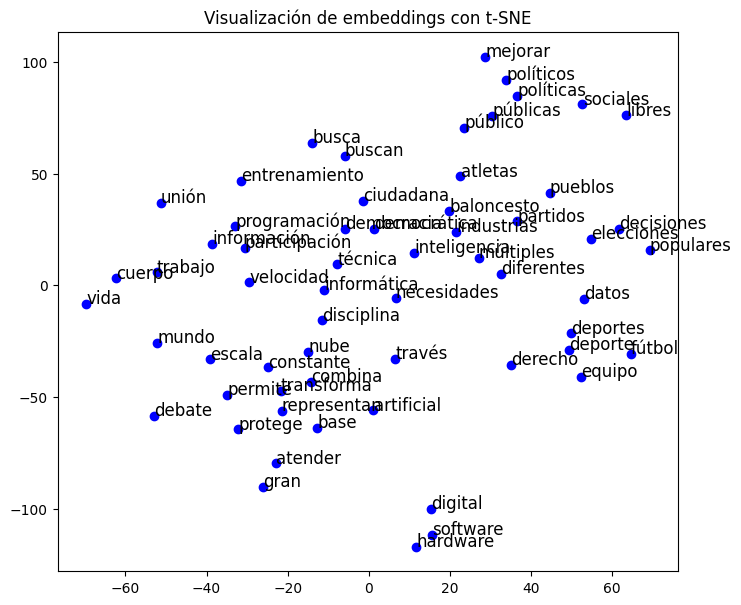

In [12]:
#4. Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca")
X_2d = tsne.fit_transform(X)
print(X_2d.shape)
print(X_2d)

#5. Visualización
plt.figure(figsize=(8, 7))
for i, palabra in enumerate(palabras_filtradas):
    x, y = X_2d[i, 0], X_2d[i, 1]
    plt.scatter(x, y, c="blue")
    plt.text(x+0.05, y+0.05, palabra, fontsize=12)
plt.title("Visualización de embeddings con t-SNE")
plt.show()


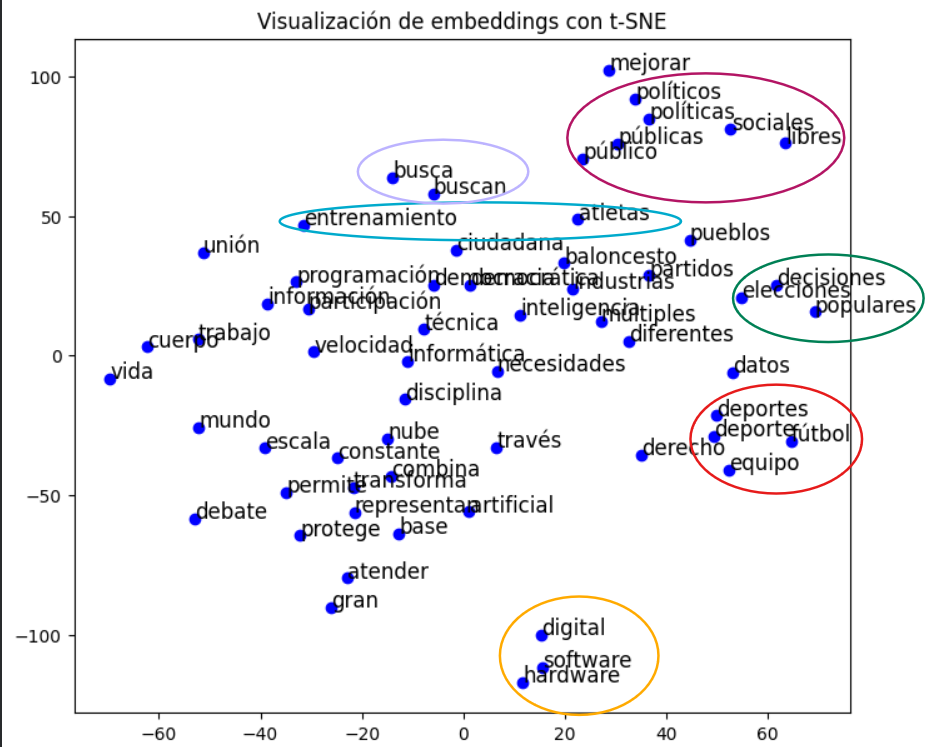

Esos son los grupos que se identifican de manera concreta, ya que existen otros segmentos que parecen no tener una separación bien definida de otros grupos de palabras